# VOCSegmentation (torchvision) + mały trening na GPU

Toy notebook do segmentacji: używa `torchvision.datasets.VOCSegmentation` (multi-class semantic segmentation) i trenuje mały U-Net na GPU (jeśli dostępny).

Maski VOC są per-piksel w zakresie klas `0..20` oraz mogą zawierać `255` jako `ignore_index`.

## 📝 Wielkie Zadanie: Budowa i Uruchomienie Sieci U-Net

**Zasoby i Dokumentacja:**
* Architektura referencyjna: [Pytorch-UNet na GitHub](https://github.com/milesial/pytorch-unet)
* Dokumentacja PyTorch: [Warstwy Konwolucyjne](https://pytorch.org/docs/stable/nn.html#convolution-layers)

### 🎯 Cel Edukacyjny
Celem nie jest uzyskanie idealnego modelu (segmentacja VOC jest trudna!), ale **zrozumienie przepływu danych w architekturze typu Encoder-Decoder** oraz poprawne połączenie warstw tak, aby proces uczenia w ogóle wystartował i zaczął generować sensowne maski.

### 🛠️ Twoje Zadania (Krok po Kroku):
1.  **Zdefiniowanie Bloku Konwolucyjnego (`ConvBlock`):** Uzupełnij warstwy tak, aby każdy blok składał się z dwóch operacji splotu (3x3), normalizacji batcha i aktywacji ReLU. Pamiętaj o zachowaniu wymiarów przestrzennych (padding!).
2.  **Konstrukcja Sieci (`SmallUNet`):** Dobierz liczby kanałów wejściowych i wyjściowych w konstruktorze `__init__`. Pamiętaj, że w dekoderze (po operacji `up`) łączysz cechy z enkodera, więc liczba kanałów wejściowych do `dec2` i `dec1` musi być sumą kanałów z 'dołu' i 'z boku' (skip-connection).
3.  **Dobór Hiperparametrów (`CONFIG`):**
    *   Zwiększ `epochs` (np. 10-20), aby model miał czas na naukę.
    *   Ustaw `max_steps_per_epoch` na `None`, by przejść przez cały zbiór.
    *   Eksperymentuj z parametrem `base` (np. 16, 32, 64) – im większy, tym model potężniejszy, ale wolniejszy.
4.  **Uruchomienie Treningu:** Sprawdź, czy `pixel_accuracy` rośnie, a funkcja kosztu maleje.

### ✅ Kryterium Sukcesu
Zadanie uznaje się za zaliczone, jeśli:
*   Kod modelu kompiluje się i wykonuje bez błędów wymiarów (*shape mismatch*).
*   Model zostanie wytrenowany przez co najmniej kilka epok.
*   Wizualizacja na końcu notebooka pokazuje, że model **próbuje** segmentować obiekty (nawet jeśli kontury są jeszcze nieprecyzyjne).

In [ ]:
# Fix for sympy/torchvision incompatibility
#OD SIEBIE: miałam dziwne problemy z niekompatybilnością przy imporcie.
#nie zwracajcie na dany fragment kodu uwagi.
!pip install sympy==1.13.3

In [ ]:
import random

import numpy as np
import torch
import torch.nn as nn
from PIL import Image
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets
from torchvision.transforms import functional as TF

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

SEED = 42
random.seed(SEED) #dla każdej biblioteki ustawiamy seed'a osobno
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device: cuda


## CONFIG

In [ ]:
# ZADANIE: Dobierz parametry tak, aby uzyskać satysfakcjonujące wyniki segmentacji.
CONFIG = {
    "data_root": "./data_voc", #ścieżka do danych treningowych
    "image_size": 128,
    "batch_size": 50, #ile obrazków w batchu
    "num_workers": 10, #ładowanie danych w tle(l.podprocesów)

    "num_classes": 21, #ilość klas dla dzielenia
    "ignore_index": 255, # , 255 piksele ignoowane w maskach segmentacji(Loss func)

    "lr": 2e-3, #learning rate
    "epochs": 60,           # Zwiększ liczbę epok
    "max_steps_per_epoch": None, #ilość batchów. Jeżeli none = 1 epoch
}

print(CONFIG)

{'data_root': './data_voc', 'image_size': 128, 'batch_size': 50, 'num_workers': 10, 'num_classes': 21, 'ignore_index': 255, 'lr': 0.002, 'epochs': 60, 'max_steps_per_epoch': None}


Notatka:

IMAGENET_MEAN i STD to są normalizatory pochodzące z ogromnego datasetu ImageNet. Są standertem dla CV. MEAN operuje średnimi wartościami RGB dla piksela, a STD - jasnością.

Interpolacja - predykcja wartości na odstawie znanych danych



In [ ]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]


class VOCResizeWrapper(Dataset):
    def __init__(self, voc_dataset, image_size):
        self.voc = voc_dataset
        self.image_size = image_size

    def __len__(self):
        return len(self.voc)

    def __getitem__(self, idx):
        img, mask = self.voc[idx]  # PIL image + PIL mask

        img = img.resize((self.image_size, self.image_size), resample=Image.BILINEAR)
        mask = mask.resize((self.image_size, self.image_size), resample=Image.NEAREST) #nearest szacowany po najbliższym sąsiedzie

        img_t = TF.to_tensor(img)
        img_t = TF.normalize(img_t, IMAGENET_MEAN, IMAGENET_STD) #normalizujemy dla stabilniejszego treningu

        mask_np = np.array(mask, dtype=np.uint8)
        mask_t = torch.from_numpy(mask_np).long()  # [H, W]
        return img_t, mask_t


train_base = datasets.VOCSegmentation(
    root=CONFIG["data_root"],
    year="2012",
    image_set="train",
    download=True,
)

val_base = datasets.VOCSegmentation(
    root=CONFIG["data_root"],
    year="2012",
    image_set="val",
    download=True,
)

train_ds = VOCResizeWrapper(train_base, CONFIG["image_size"])
val_ds = VOCResizeWrapper(val_base, CONFIG["image_size"])

train_loader = DataLoader(
    train_ds,
    batch_size=CONFIG["batch_size"],
    shuffle=True,
    num_workers=CONFIG["num_workers"],
    pin_memory=True,
)

val_loader = DataLoader(
    val_ds,
    batch_size=CONFIG["batch_size"],
    shuffle=False,
    num_workers=CONFIG["num_workers"],
    pin_memory=True,
)

img_t, mask_t = train_ds[0]
print("img_t:", img_t.shape, "mask_t:", mask_t.shape)
print("mask unique sample:", torch.unique(mask_t)[:10])


img_t: torch.Size([3, 128, 128]) mask_t: torch.Size([128, 128])
mask unique sample: tensor([  0,   1,  15, 255])


/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 10 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


### Podgląd danych wejściowych (VOC)
Wyświetlamy kilka przykładowych obrazów ze zbioru treningowego wraz z ich maskami segmentacji.

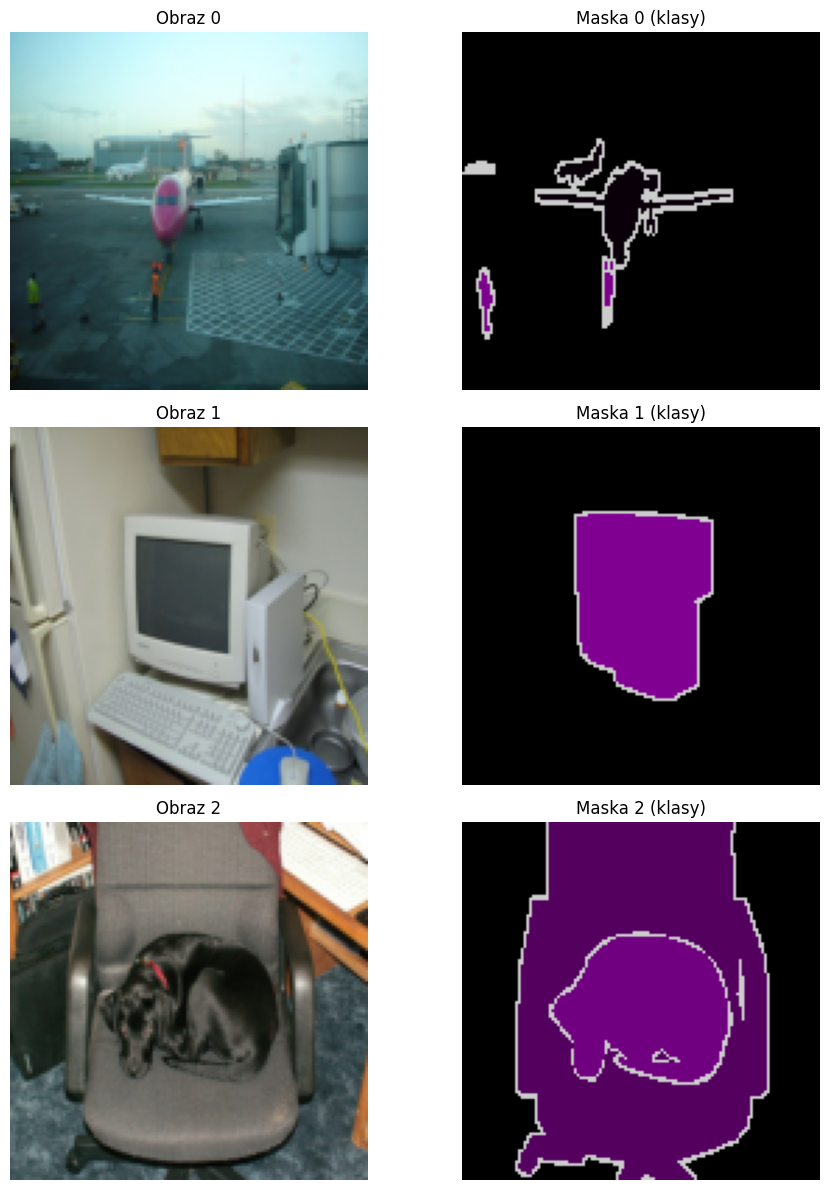

In [ ]:
import matplotlib.pyplot as plt

def visualize_input_samples(dataset, num_samples=3):
    fig, axes = plt.subplots(num_samples, 2, figsize=(10, 4 * num_samples))
    for i in range(num_samples):
        img, mask = dataset[i]
        # Denormalizacja obrazu do wyświetlenia
        img_display = img.permute(1, 2, 0).numpy()
        img_display = img_display * IMAGENET_STD + IMAGENET_MEAN
        img_display = np.clip(img_display, 0, 1)

        axes[i, 0].imshow(img_display)
        axes[i, 0].set_title(f"Obraz {i}")
        axes[i, 0].axis('off')

        # Maska (mapujemy 255 na 0 dla lepszej widoczności lub zostawiamy jako raw)
        axes[i, 1].imshow(mask.numpy(), cmap='nipy_spectral')
        axes[i, 1].set_title(f"Maska {i} (klasy)")
        axes[i, 1].axis('off')
    plt.tight_layout()
    plt.show()

visualize_input_samples(train_ds)

#Notatka:
- self.net - sieć neuronowa sama w sobie.(albo sekwencja warstw)
- nn.Sequential - automatycznie łączy i zachowuje warstwy między sobą. KOntener
- Warstwy przyisujemy ręcznie, po kolei. Czyli, faktycznie, modele budujemy samodzielnie z własną architekturą.(Nie jest to prościutki scikit)
- Najlepiej tworzyć model jako klasę a potem eksperymentować ze zmianą hiperparametrów oraz innych szczegółów.



#ZADANIE

##Plan warstw:
1. Enkoder(Co)(zmniejszamy rozdzielczość, zwiększamy kanały):

      - Conv2d (konwolucja)("plamuje" obraz)
      - BatchNorm2d (normalizacja)
      - ReLU (aktywacja)
      
      (powtarzamy jeszcze raz)

      - MaxPool2d (pooling)(zostawiay tylko najważniejsze plamy + zmniejszamy rozdz.)
2. Bottleneck(wąskie gardło)(tutaj zapada decyzja "co to jest"):

      - To samo co enkoder, ale 1 raz i bez MaxPool2d(no bo po co, i tak najwęższy punkt).

3. Up(powiększamy, ale rozmywamy)+skip connection(łaczymy tensory up i skip, by odzyskać kontury):
      
      - ConvTranspose2d(odwrotna konwolucja de facto)
      - torch.cat

4. Dekoder(Gdzie)

      - Conv2d(tylko teraz robimy więcej wyjść, jakby na odwrót od dekodera)
      - (Nie robimy normalizacji, ponieważ robi się ją tylko 1 raz dla większej stabilności uczenia się. Po to są ImageNet normalizatory)
      - ReLU(aktywacja)
5. Output Layer

      - Conv2d(liczba out_channels musi być 1)


##Dodatkowe info:
- kernel_size = 3 dobrałam dlatego, że jest to ogólnie standartowy rozmiar: nie za duży(bo byłoby o wiele więcej parametrów), i nie za mały. A do tego, z tego co doczytałam, to 2 konwolucji z kernelem 3 * 3 są porównywalne z jedną konwolucją z kernelem 5 * 5, przy tym będą efektywniejsze.



In [ ]:
import torch.nn as nn
import torch

class ConvBlock(nn.Module):
    """
    ZADANIE: Zaimplementuj blok: [Conv 3x3, BN, ReLU] x 2.
    Pamiętaj o padding=1, aby nie zmniejszać wymiarów obrazu.
    """
    def __init__(self, in_ch, out_ch):
        super().__init__()
        #self.net to nn.Sequential z odpowiednimi warstwami. Dla recyclingu kodu
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            #powtórzenie
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True)
       )
    def forward(self, x):
        return self.net(x)


class SmallUNet(nn.Module):
    """
    ZADANIE: Zdefiniuj warstwy encodera, bottlenecku i decodera w __init__.
    Dobierz kanały tak, aby pasowały do logiki konkatenacji w forward.
    """
    def __init__(self, in_channels=3, base=16, num_classes=21):
        super().__init__()
        # --- Encoder ---
        #self.enc1, self.pool1, self.enc2, self.pool2
        self.enc1 = ConvBlock(in_channels, base)
        self.enc2 = ConvBlock(base, base * 2)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

        # --- Bottleneck ---
        self.bottleneck = ConvBlock(base * 2, base * 4)

        # --- Decoder ---
        #self.up2, self.dec2, self.up1, self.dec1
        # Wskazówka: self.dec2 przyjmuje kanały z (up2 + enc2)
        self.up2 = nn.ConvTranspose2d(base * 4, base * 2, kernel_size=2, stride=2)

        self.up1 = nn.ConvTranspose2d(base * 2, base, kernel_size=2, stride=2)
        self.dec2 = ConvBlock(base * 4, base * 2)
        self.dec1 = ConvBlock(base * 2, base)
        #pamiętaj: 1 up = 1 skip. Nie jest to jednorazowa operacja
        # --- Output ---
        self.final = nn.Conv2d(base, num_classes, kernel_size=1) #wyjście musi być równe ilości klas. Zawsze.

#x to wprowadzone dane;
#pamiętaj o sprowadzeniu danych do tensora w torchu(i wysyłce danych w gpu na końcu)
    def forward(self, x):
        # --- Encoder ---
        s1 = self.enc1(x)
        p1 = self.pool1(s1)
        s2 = self.enc2(p1)
        p2 = self.pool2(s2)

        # --- Bottleneck ---
        b = self.bottleneck(p2)

        # --- Decoder ze Skip-Connections ---
        u2 = self.up2(b)
        d2 = self.dec2(torch.cat([u2, s2], dim=1))

        u1 = self.up1(d2)
        d1 = self.dec1(torch.cat([u1, s1], dim=1))

        return self.final(d1)

# Inicjalizacja modelu - studenci mogą tu zmieniać parametr 'base'
model = SmallUNet(base=64).to(device)

In [ ]:
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total trainable parameters: {total_params:,}")

Total trainable parameters: 1,865,429


In [ ]:
import numpy as np
import torch

def iou_score_per_class(logits, targets, num_classes, ignore_index):
    preds = logits.argmax(dim=1) # [B, H, W]

    # Flatten tensors for easier comparison
    preds_flat = preds.view(-1)
    targets_flat = targets.view(-1)

    # Mask out ignored pixels
    valid_mask = (targets_flat != ignore_index)
    preds_valid = preds_flat[valid_mask]
    targets_valid = targets_flat[valid_mask]

    if targets_valid.numel() == 0: # No valid pixels to evaluate
        return 0.0 # Return 0.0 mean IoU

    iou_per_class_list = []

    for cls_idx in range(num_classes):
        if cls_idx == ignore_index:
            continue

        intersection = ((preds_valid == cls_idx) & (targets_valid == cls_idx)).sum().item()
        union = ((preds_valid == cls_idx) | (targets_valid == cls_idx)).sum().item()

        if union == 0:
            # If the class is not present in either predictions or targets (in valid areas),
            # consider IoU for that class as 1.0 (perfect prediction of absence).
            if intersection == 0:
                iou_per_class_list.append(1.0)
            else: # This case (intersection > 0 but union == 0) should ideally not happen
                iou_per_class_list.append(0.0)
        else:
            iou_per_class_list.append(intersection / union)

    if len(iou_per_class_list) == 0:
        return 0.0 # If no valid classes to evaluate

    return sum(iou_per_class_list) / len(iou_per_class_list)

def f1_score_per_class(logits, targets, num_classes, ignore_index):
    preds = logits.argmax(dim=1) # [B, H, W]

    preds_flat = preds.view(-1)
    targets_flat = targets.view(-1)

    valid_mask = (targets_flat != ignore_index)
    preds_valid = preds_flat[valid_mask]
    targets_valid = targets_flat[valid_mask]

    if targets_valid.numel() == 0:
        return 0.0

    f1_per_class_list = []

    for cls_idx in range(num_classes):
        if cls_idx == ignore_index:
            continue

        tp = ((preds_valid == cls_idx) & (targets_valid == cls_idx)).sum().item()
        fp = ((preds_valid == cls_idx) & (targets_valid != cls_idx)).sum().item()
        fn = ((preds_valid != cls_idx) & (targets_valid == cls_idx)).sum().item()

        precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0

        if precision + recall == 0:
            f1 = 0.0
        else:
            f1 = 2 * (precision * recall) / (precision + recall)
        f1_per_class_list.append(f1)

    if len(f1_per_class_list) == 0:
        return 0.0

    return sum(f1_per_class_list) / len(f1_per_class_list)


weights = torch.ones(CONFIG["num_classes"]).to(device) # Przenieś wagi na to samo urządzenie co model i dane
weights[0] = 0.2
criterion = nn.CrossEntropyLoss(weight=weights, ignore_index=CONFIG["ignore_index"])
optimizer = torch.optim.Adam(model.parameters(), lr=CONFIG["lr"])

def pixel_accuracy(logits, targets):
    preds = logits.argmax(dim=1)
    valid = targets != CONFIG["ignore_index"]
    if valid.sum() == 0:
        return 0.0
    return (preds[valid] == targets[valid]).float().mean().item()

best_val_acc = -1.0

# Lists to store metrics per epoch
epoch_pixel_accs = []
epoch_ious = []
epoch_f1s = []

for epoch in range(CONFIG["epochs"]):
    model.train()
    running_loss = 0.0
    steps = 0

    for step, (imgs, masks) in enumerate(train_loader):
        if CONFIG["max_steps_per_epoch"] is not None and step >= CONFIG["max_steps_per_epoch"]:
            break
        imgs = imgs.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)
        logits = model(imgs)
        loss = criterion(logits, masks)
        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        steps += 1

    model.eval()
    # For validation, calculate pixel_accuracy, IoU, and F1-score
    val_pixel_accs_batch = []
    val_ious_batch = []
    val_f1s_batch = []

    with torch.no_grad():
        for imgs, masks in val_loader:
            imgs = imgs.to(device, non_blocking=True)
            masks = masks.to(device, non_blocking=True)
            logits = model(imgs)

            val_pixel_accs_batch.append(pixel_accuracy(logits, masks))
            val_ious_batch.append(iou_score_per_class(logits, masks, CONFIG["num_classes"], CONFIG["ignore_index"])) # Re-using iou_score_per_class
            val_f1s_batch.append(f1_score_per_class(logits, masks, CONFIG["num_classes"], CONFIG["ignore_index"])) # Re-using f1_score_per_class

    val_pixel_acc = np.mean(val_pixel_accs_batch) if val_pixel_accs_batch else 0.0
    val_iou = np.mean(val_ious_batch) if val_ious_batch else 0.0
    val_f1 = np.mean(val_f1s_batch) if val_f1s_batch else 0.0

    train_loss = running_loss / max(1, steps)
    best_val_acc = max(best_val_acc, val_pixel_acc)

    epoch_pixel_accs.append(val_pixel_acc)
    epoch_ious.append(val_iou)
    epoch_f1s.append(val_f1)

    print(f"Epoch {epoch+1}/{CONFIG['epochs']} | train_loss={train_loss:.4f} | val_pixel_acc={val_pixel_acc:.4f} | val_iou={val_iou:.4f} | val_f1={val_f1:.4f}")

print("best_val_acc:", best_val_acc)


/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 10 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Epoch 1/60 | train_loss=2.6816 | val_pixel_acc=0.5141 | val_iou=0.0725 | val_f1=0.0508
Epoch 2/60 | train_loss=2.2959 | val_pixel_acc=0.6218 | val_iou=0.0801 | val_f1=0.0563
Epoch 3/60 | train_loss=2.2175 | val_pixel_acc=0.5756 | val_iou=0.0742 | val_f1=0.0563
Epoch 4/60 | train_loss=2.1645 | val_pixel_acc=0.7060 | val_iou=0.0733 | val_f1=0.0669
Epoch 5/60 | train_loss=2.1043 | val_pixel_acc=0.6111 | val_iou=0.0762 | val_f1=0.0612
Epoch 6/60 | train_loss=2.0641 | val_pixel_acc=0.7265 | val_iou=0.0841 | val_f1=0.0711
Epoch 7/60 | train_loss=2.0115 | val_pixel_acc=0.5725 | val_iou=0.0714 | val_f1=0.0627
Epoch 8/60 | train_loss=2.0230 | val_pixel_acc=0.6288 | val_iou=0.0673 | val_f1=0.0735
Epoch 9/60 | train_loss=1.9865 | val_pixel_acc=0.6725 | val_iou=0.0823 | val_f1=0.0774
Epoch 10/60 | train_loss=1.9681 | val_pixel_acc=0.7122 | val_iou=0.0840 | val_f1=0.0869
Epoch 11/60 | train_loss=1.9219 | val_pixel_acc=0.6342 | val_iou=0.0780 | val_f1=0.0794
Epoch 12/60 | train_loss=1.9354 | val_pix

### Wizualizacja wyników treningu
Nakładamy przewidziane maski na obrazy walidacyjne oraz wyświetlamy legendę klas VOC.

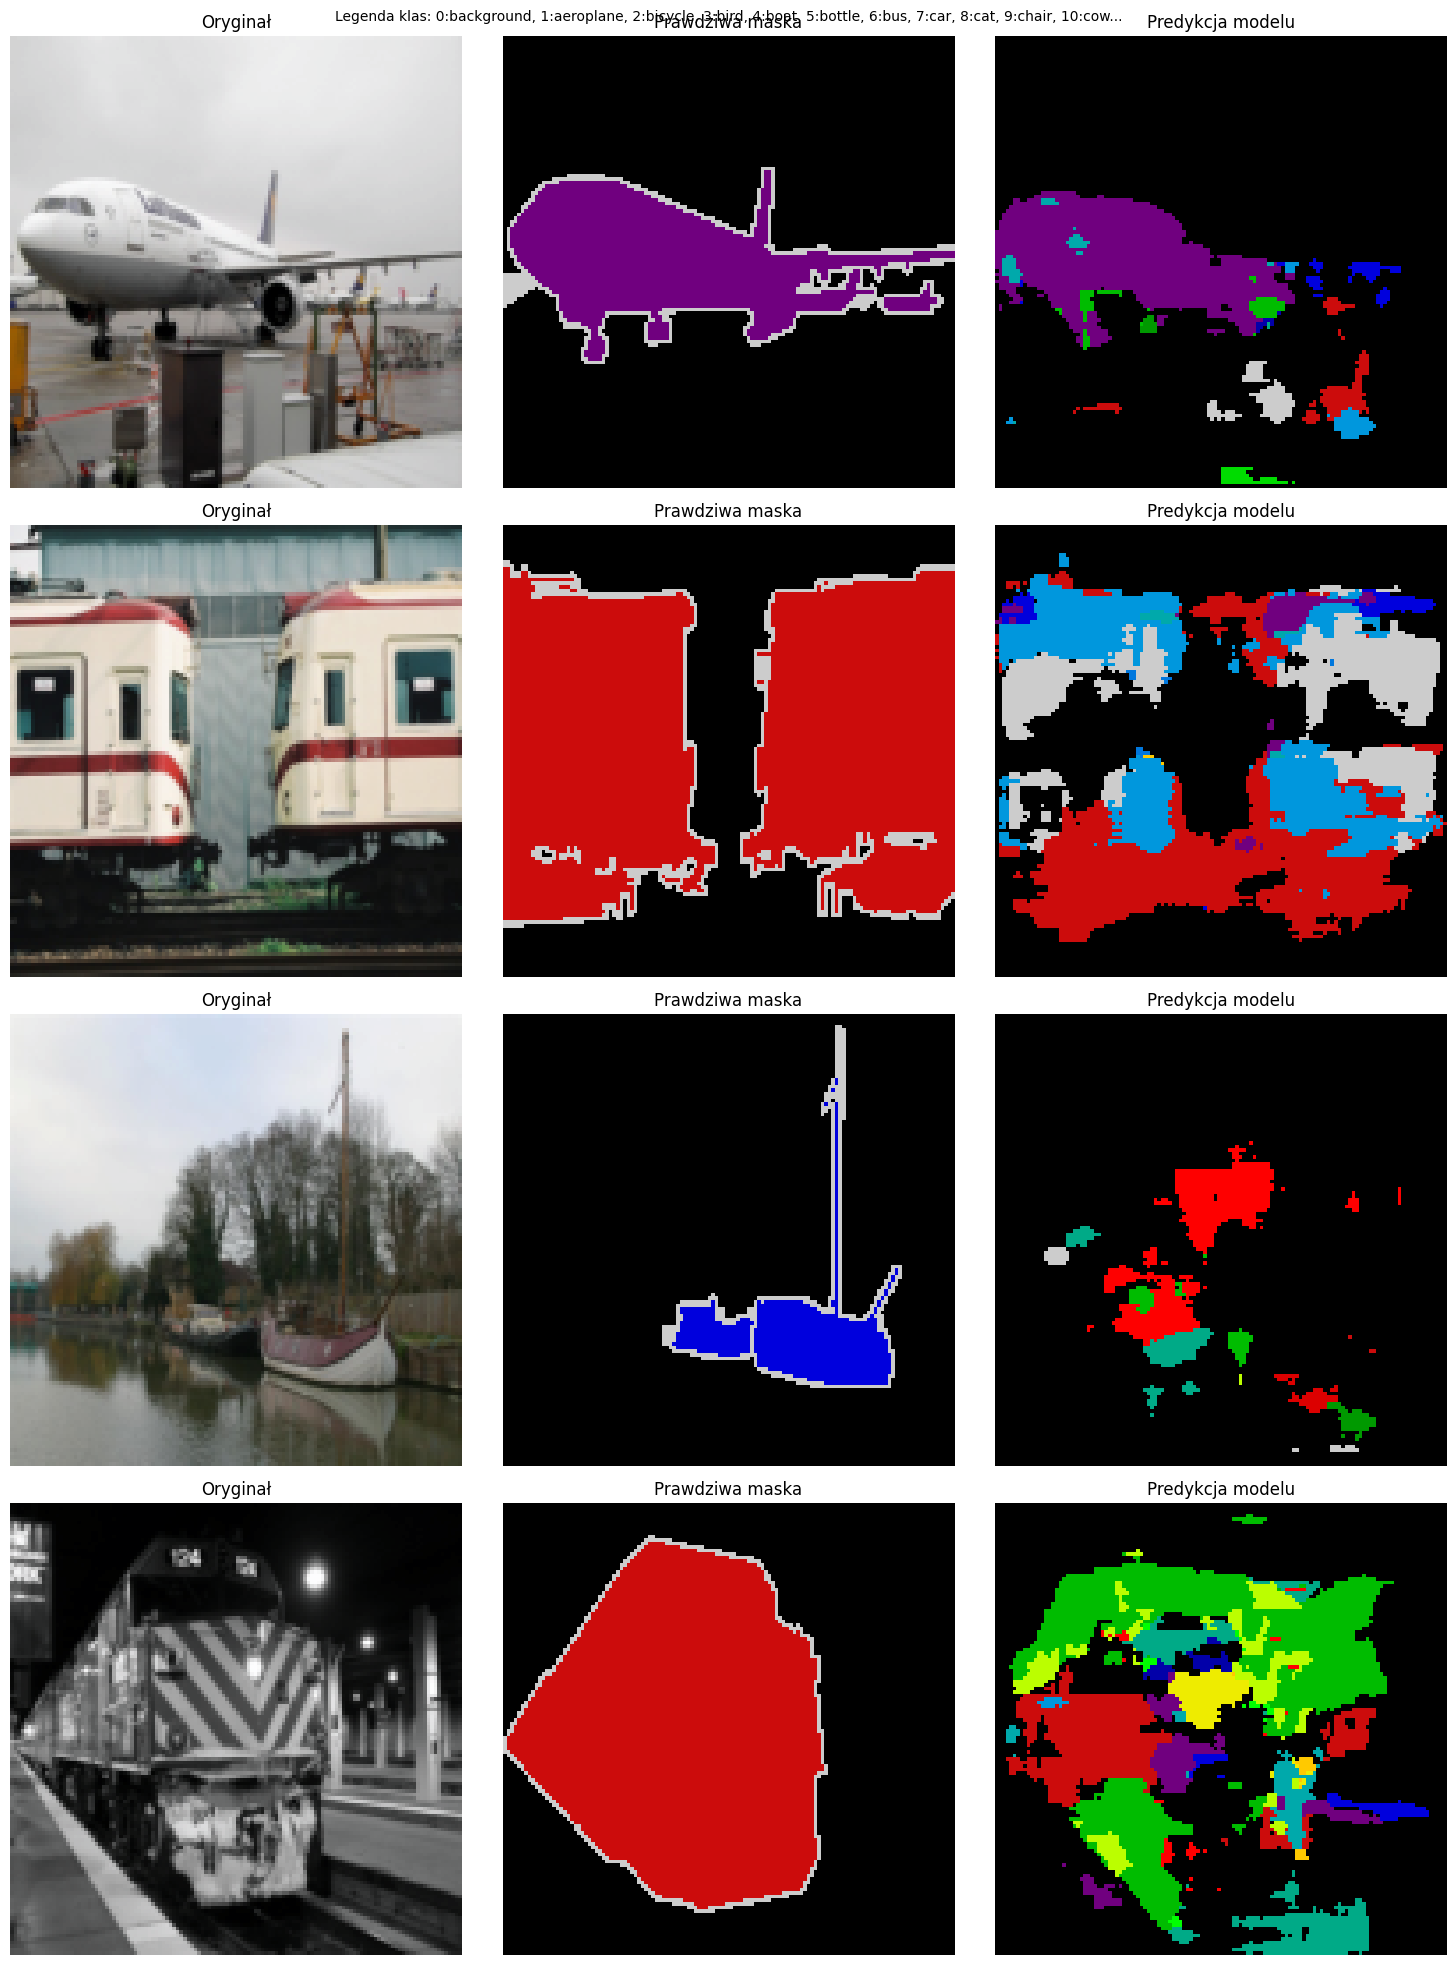

In [ ]:
VOC_CLASSES = [
    'background', 'aeroplane', 'bicycle', 'bird', 'boat', 'bottle', 'bus', 'car', 'cat', 'chair', 'cow',
    'diningtable', 'dog', 'horse', 'motorbike', 'person', 'pottedplant', 'sheep', 'sofa', 'train', 'tvmonitor'
]

def visualize_predictions(model, dataset, device, num_samples=4):
    model.eval()
    fig, axes = plt.subplots(num_samples, 3, figsize=(15, 5 * num_samples))

    with torch.no_grad():
        for i in range(num_samples):
            img, mask = dataset[i]
            input_batch = img.unsqueeze(0).to(device)
            logits = model(input_batch)
            preds = logits.argmax(dim=1).cpu().squeeze(0)

            # Obraz oryginalny
            img_display = img.permute(1, 2, 0).numpy() * IMAGENET_STD + IMAGENET_MEAN
            img_display = np.clip(img_display, 0, 1)

            axes[i, 0].imshow(img_display)
            axes[i, 0].set_title("Oryginał")

            # Prawdziwa maska
            axes[i, 1].imshow(mask, cmap='nipy_spectral', vmin=0, vmax=20)
            axes[i, 1].set_title("Prawdziwa maska")

            # Predykcja
            axes[i, 2].imshow(preds, cmap='nipy_spectral', vmin=0, vmax=20)
            axes[i, 2].set_title("Predykcja modelu")

            for ax in axes[i]: ax.axis('off')

    plt.suptitle("Legenda klas: " + ", ".join([f"{i}:{c}" for i, c in enumerate(VOC_CLASSES[:11])]) + "...", fontsize=10)
    plt.tight_layout()
    plt.show()

visualize_predictions(model, val_ds, device)

In [ ]:
import numpy as np
import torch

def iou_score_per_class(logits, targets, num_classes, ignore_index):
    preds = logits.argmax(dim=1) # [B, H, W]

    # Flatten tensors for easier comparison
    preds_flat = preds.view(-1)
    targets_flat = targets.view(-1)

    # Mask out ignored pixels
    valid_mask = (targets_flat != ignore_index)
    preds_valid = preds_flat[valid_mask]
    targets_valid = targets_flat[valid_mask]

    if targets_valid.numel() == 0: # No valid pixels to evaluate
        return 0.0 # Return 0.0 mean IoU

    iou_per_class_list = []

    for cls_idx in range(num_classes):
        if cls_idx == ignore_index:
            continue

        intersection = ((preds_valid == cls_idx) & (targets_valid == cls_idx)).sum().item()
        union = ((preds_valid == cls_idx) | (targets_valid == cls_idx)).sum().item()

        if union == 0:
            # If the class is not present in either predictions or targets (in valid areas),
            # consider IoU for that class as 1.0 (perfect prediction of absence).
            if intersection == 0:
                iou_per_class_list.append(1.0)
            else: # This case (intersection > 0 but union == 0) should ideally not happen
                iou_per_class_list.append(0.0)
        else:
            iou_per_class_list.append(intersection / union)

    if len(iou_per_class_list) == 0:
        return 0.0 # If no valid classes to evaluate

    return sum(iou_per_class_list) / len(iou_per_class_list)

def f1_score_per_class(logits, targets, num_classes, ignore_index):
    preds = logits.argmax(dim=1) # [B, H, W]

    preds_flat = preds.view(-1)
    targets_flat = targets.view(-1)

    valid_mask = (targets_flat != ignore_index)
    preds_valid = preds_flat[valid_mask]
    targets_valid = targets_flat[valid_mask]

    if targets_valid.numel() == 0:
        return 0.0

    f1_per_class_list = []

    for cls_idx in range(num_classes):
        if cls_idx == ignore_index:
            continue

        tp = ((preds_valid == cls_idx) & (targets_valid == cls_idx)).sum().item()
        fp = ((preds_valid == cls_idx) & (targets_valid != cls_idx)).sum().item()
        fn = ((preds_valid != cls_idx) & (targets_valid == cls_idx)).sum().item()

        precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0

        if precision + recall == 0:
            f1 = 0.0
        else:
            f1 = 2 * (precision * recall) / (precision + recall)
        f1_per_class_list.append(f1)

    if len(f1_per_class_list) == 0:
        return 0.0

    return sum(f1_per_class_list) / len(f1_per_class_list)

def evaluate_all_metrics(model, dataloader, device, num_classes, ignore_index):
    model.eval()
    all_pixel_accs = []
    all_ious = []
    all_f1s = []

    with torch.no_grad():
        for imgs, masks in dataloader:
            imgs = imgs.to(device, non_blocking=True)
            masks = masks.to(device, non_blocking=True)
            logits = model(imgs)

            # Pixel Accuracy (reusing the existing function from a previous cell)
            all_pixel_accs.append(pixel_accuracy(logits, masks))

            # IoU
            all_ious.append(iou_score_per_class(logits, masks, num_classes, ignore_index))

            # F1 Score
            all_f1s.append(f1_score_per_class(logits, masks, num_classes, ignore_index))

    avg_pixel_acc = np.mean(all_pixel_accs) if all_pixel_accs else 0.0
    avg_iou = np.mean(all_ious) if all_ious else 0.0
    avg_f1 = np.mean(all_f1s) if all_f1s else 0.0

    return avg_pixel_acc, avg_iou, avg_f1

# Retrieve necessary variables from the notebook's global scope
# CONFIG, model, val_loader, device, pixel_accuracy are assumed to be defined from previous cells.
num_classes = CONFIG["num_classes"]
ignore_index = CONFIG["ignore_index"]

avg_pixel_acc, avg_iou, avg_f1 = evaluate_all_metrics(model, val_loader, device, num_classes, ignore_index)

print(f"Validation Pixel Accuracy: {avg_pixel_acc:.4f}")
print(f"Validation Mean IoU: {avg_iou:.4f}")
print(f"Validation Mean F1-Score: {avg_f1:.4f}")

Validation Pixel Accuracy: 0.6716
Validation Mean IoU: 0.1112
Validation Mean F1-Score: 0.1691


#Wnioski oraz sugestie

- Faktycznie, model się uczy, i to widać(szczególnie we wskaźnikach przy każdej kolejnej epoce). Jednak po próbach, niektóre wskaźniki po n-ej ilości epok zaczynały stagnować lub nie rosły. Max liczba, którą wykorzystywałam - 100 epok(przy base = 128, ale nie dogenerowałam przez limity colabu :'{). Dokładnie, wszystko oprócz training loss.

-Zauważyłam po wielu treningach oraz wariacjach kilka ważnych problemów:
1. Wcześniej mój model robił zbyt chaotyczne plamy oraz bardzo błędne klasy. Jak się okazało, obrazy zawierały dominującą klasę, czyli tło, która tłumiła inne. Wprowadziłam system wag, gdzie tło teraz znaczy mniej i nie warto na nim się skupiać. Wyniki się znacznie się ulepszyły.
2. Mój model bardzo często "rozpoznaje" zbyt wiele klas na jednym obrazku(chociaż wciąż może wyodrębnić dominującą). W sumie, to też można by było to rozwiązać wagami, ale nie mam pojęcia jak zrobić je dynamicznymi(czyli 2-3 największe, max 5 klas będą na obrazie, inne - won. Ale nie wiem, czy to ma sens...)
3. Skalowanie modelu. Żeby osiągnąć jaknajbliższy do 100% accuracy wynik, potrzeba jest większego modelu. Jednak przez ograniczenia platformy (oraz mojego portfela XDDD) nie mogę zrealizować skalowanie w sensowny sposób. Ja bym dała base 128, a epoki już bym pasowała wg. testów.
4. Problemem może być też typ wybranej architektury, ale z kolei tutaj nie mogę zbytnio się wypowiadać(wymogi oraz dane wejściowe zadania)


*(Trochę od siebie, nie część zadania: "Ale się namęczyłam z tym wrednym modelem. Chyba ściana by się szybciej nauczyła obrazki rozpoznawać XDD")*


